# 第52篇 | K近邻 KNN：最直觉的分类算法

> 这是「数据分析从入门到精通」系列的第 52 篇。SVM 理解了，这篇来学一个更直觉的算法——KNN。"看一个人交什么朋友，就知道他是什么样的人"，这句话说的就是 KNN 的核心思想，简单粗暴，但在很多场景里效果出奇地好。

嗨，我是小荷～ 今天学一个超级直观的算法：**K近邻（KNN）**。

---

## 一、KNN的核心思想

K 近邻（K-Nearest Neighbors, 简称 KNN） 是一种最基础的机器学习算法。它不仅能用于分类，也能用于回归。其核心思想是“物以类聚”——通过计算待测样本与训练集中所有已知类别数据的距离，选取距离最近的 \(K\) 个样本，利用“少数服从多数”的原则来预测其归属类别。

**一句话概括**：近朱者赤，近墨者黑。

**算法流程**：
1. 计算距离：计算新数据点与训练集中各个数据点之间的距离（常用欧氏距离或曼哈顿距离）。
2. 排序与筛选：按距离升序排序，挑选出距离最近的前 k 个数据点。
3. 多数表决：统计这 k 个点中各类别出现的次数，将出现次数最多的类别作为新数据点的预测类别。

k 值表示在预测时需要参考的最近邻数据点数量。较小的 k 值可能导致模型对噪声过于敏感，而较大的 k 值可能降低模型的预测精度，因此通常通过交叉验证等方法来选择合适的 k 值。

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification, make_moons
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
import warnings
warnings.filterwarnings('ignore')

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

print("K近邻 KNN 入门")

# 生成示例数据， 2个类别
np.random.seed(42)
X, y = make_classification(n_samples=60, n_features=2, n_redundant=0,
                           n_informative=2, n_clusters_per_class=1,
                           class_sep=1.5, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"训练集: {X_train.shape}, 测试集: {X_test.shape}")
print(f"类别分布: {np.bincount(y)}")


K近邻 KNN 入门
训练集: (42, 2), 测试集: (18, 2)
类别分布: [30 30]


[150 150] 说明两个类别分布均衡。

---

## 二、可视化KNN的预测过程

KNN 的"就近投票"思想，画个图就一目了然：


In [7]:
# 选择一个测试点进行可视化
test_point_idx = 0
test_point = X_test[test_point_idx].reshape(1, -1)

# 计算到所有训练点的距离
distances = np.sqrt(np.sum((X_train - test_point) ** 2, axis=1))

# 找到K个最近邻
K = 5
nearest_indices = np.argsort(distances)[:K]
nearest_labels = y_train[nearest_indices]

print(f"测试点坐标: {test_point[0].round(3)}")
print(f"\n最近的{K}个邻居:")
print("-" * 40)
for i, idx in enumerate(nearest_indices):
    print(f"邻居{i+1}: 距离={distances[idx]:.3f}, 类别={y_train[idx]}")

print(f"\nK个邻居的类别分布: {np.bincount(nearest_labels)}")
predicted_class = np.bincount(nearest_labels).argmax()
print(f"预测结果: 类别{predicted_class}")
print(f"真实标签: 类别{y_test[test_point_idx]}")


测试点坐标: [1.795 0.294]

最近的5个邻居:
----------------------------------------
邻居1: 距离=0.356, 类别=1
邻居2: 距离=0.908, 类别=1
邻居3: 距离=0.950, 类别=1
邻居4: 距离=1.024, 类别=1
邻居5: 距离=1.037, 类别=1

K个邻居的类别分布: [0 5]
预测结果: 类别1
真实标签: 类别1


文字看不过瘾？把 KNN 的预测过程画出来：


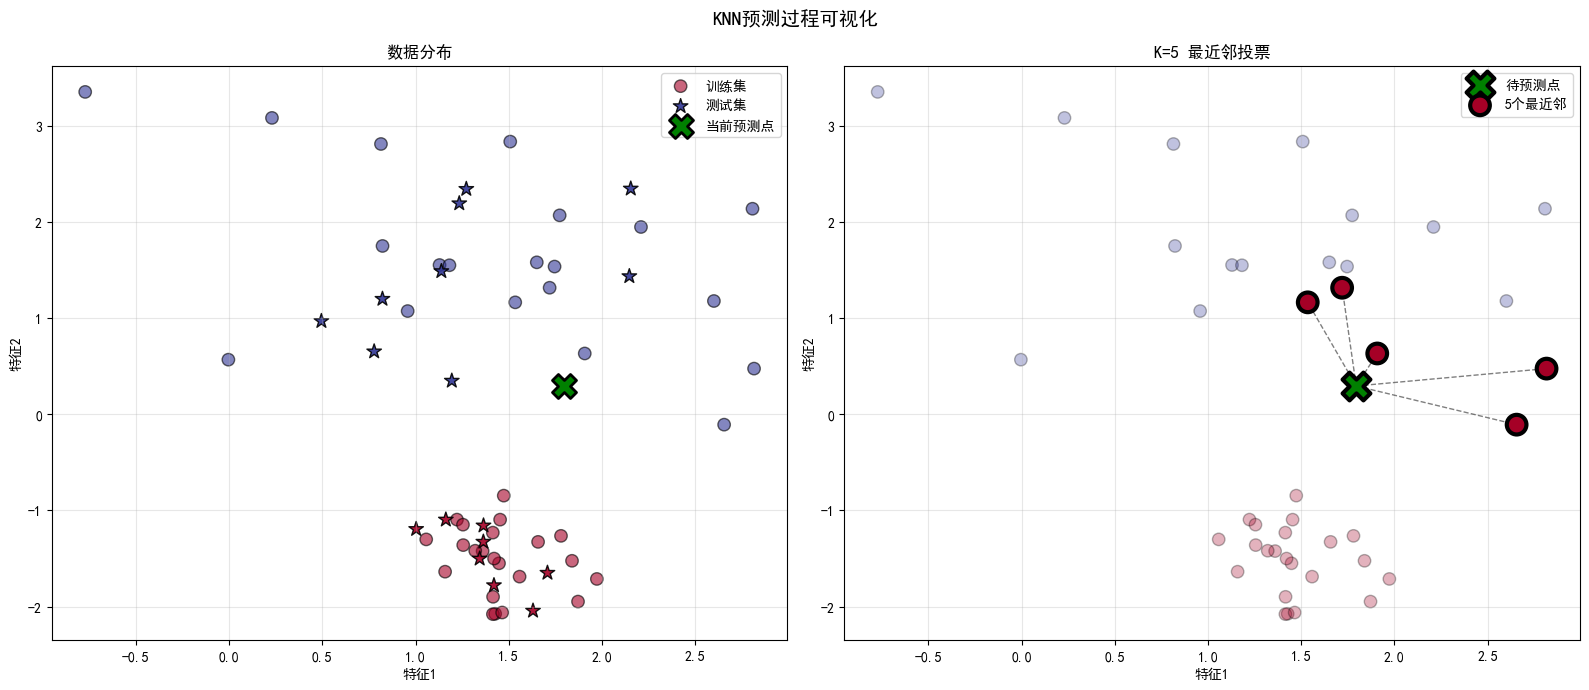

In [8]:
# 可视化KNN预测过程
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# 左图：整体数据分布
ax1 = axes[0]
ax1.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='RdYlBu',
           s=80, alpha=0.6, edgecolors='k', label='训练集')
ax1.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap='RdYlBu',
           s=120, alpha=0.9, edgecolors='k', marker='*', label='测试集')
# 在当前测试点，画一个超级显眼的绿色大叉叉
# test_point 是一整块数据，长这样：[[x坐标, y坐标],[x1坐标, y1坐标]...]
ax1.scatter(test_point[0, 0], test_point[0, 1], c='green',
           s=300, marker='X', edgecolors='k', linewidths=2, label='当前预测点')
ax1.set_xlabel('特征1')
ax1.set_ylabel('特征2')
ax1.set_title('数据分布')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 右图：K个最近邻
ax2 = axes[1]
ax2.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='RdYlBu',
           s=80, alpha=0.3, edgecolors='k')
ax2.scatter(test_point[0, 0], test_point[0, 1], c='green',
           s=400, marker='X', edgecolors='k', linewidths=3, label='待预测点', zorder=5)

# 高亮K个邻居
neighbor_points = X_train[nearest_indices]
ax2.scatter(neighbor_points[:, 0], neighbor_points[:, 1],
           c=y_train[nearest_indices], cmap='RdYlBu',
           s=200, edgecolors='black', linewidths=3, label=f'{K}个最近邻', zorder=4)

# 画连接线
for idx in nearest_indices:
    ax2.plot([test_point[0, 0], X_train[idx, 0]],
            [test_point[0, 1], X_train[idx, 1]],
            'k--', alpha=0.5, linewidth=1)

ax2.set_xlabel('特征1')
ax2.set_ylabel('特征2')
ax2.set_title(f'K={K} 最近邻投票')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('KNN预测过程可视化', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


图片说明：
- 绿点：类别1的样本
- 红点：类别2的样本
- 绿五角星：类别1的预测点
- 红五角星：类别2的预测点
- 绿色 X：要预测的新样本
- 高亮大圆点：选出的 K 个最近邻居
- 黑色虚线	：显示距离连接

左图展示整体数据分布，包含训练集、测试集与待预测的目标点；
右图聚焦 KNN 核心逻辑，自动寻找距离目标点最近的 K 个邻居，通过虚线连接并高亮显示；
KNN 基于 “多数投票” 原则，根据邻居的类别判断待预测点的类别，直观体现了 “物以类聚” 的分类思想。

---

## 三、K值的选择：核心超参数

如果用一句话来翻译，KNN 算法的底层逻辑其实就是一句话：**“物以类聚，人以群分。你想知道自己是谁，看看你周围离你最近的几个朋友是谁就知道了。”**

而这个 **$K$ 值，说白了，就是你做决定时，准备参考的“朋友圈人数”**。

---

## 🍊 一个买橘子的最直观例子

假设你现在开了一家水果店，刚进了一批新橘子，你不知道它是“甜的”还是“酸的”。
你把它摆在坐标图上，周围密密麻麻全是以前卖过的旧橘子，它们都有标签（红色代表甜，绿色代表酸）。

你现在要预测这个新橘子的口味，这就是 $K$ 值登场的时候了：

* **如果设置 $K = 1$：**
你只参考离它**最近的 1 个**邻居。如果离它最近的那个橘子是酸的，那对不起，这个新橘子直接被判定为“酸的”。
* **如果设置 $K = 3$：**
你扩大朋友圈，参考离它**最近的 3 个**邻居。这时候要搞“少数服从多数”的投票。如果这 3 个邻居里有 2 个是甜的，1 个是酸的，2 比 1，新橘子就被判定为“甜的”。
* **如果设置 $K = 11$：**
你找离它最近的 11 个邻居来共同投票，谁的票数多，新橘子就跟谁姓。


## ⚖️ $K$ 值大小的系统悖论：太大或太小会发生什么？

在调校这个参数的时候，系统会面临两个极端的Bug。这完美对应了我们之前聊过的“过拟合”与“钝感”。

### 1. $K$ 值选得太小（比如 $K = 1$）——【高敏、过拟合、神经质】

如果 $K$ 值太小，系统就会变得极其高敏。

* **后果：** 只要离新橘子最近的那一个邻居刚好是个“烂掉的变质酸橘子”（数据噪声），系统就会立刻被这个噪声带偏，做出错误的判断。
* **用人话来说：** 这就像一个人极度敏感，今天走在路上，**仅仅因为路过的 1 个陌生人**对他翻了个白眼，他就立刻得出结论：“这个世界充满了恶意，我完蛋了。”这就是典型的被局部噪声劫持，系统陷入了**过拟合**。

### 2. $K$ 值选得太大（比如 $K = 100$）——【盲目、钝感、大锅饭】

如果 $K$ 值太大，系统就会变得极度麻木。

* **后果：** 假设你的水果店总共就 110 个橘子，其中 100 个是酸的，10 个是甜的。你把 $K$ 设成 100。这时候，不管这个新橘子长在哪个甜橘子堆里，只要一投票，那 100 个酸橘子的大部队就会靠着人数优势强行碾压。新橘子永远会被判定为“酸的”。
* **用人话来说：** 这就像一个人完全失去了个性，做任何决定都要参考**全村 100 个人**的意见。不管你自己的特质有多么独特、离梦想有多近，全村大部队的平庸意见啪地一下就把你同化了。系统陷入了**欠拟合（Too Blunt）**。

---

## 🏁 总结：如何找到完美的 $K$ 值？

- 选择奇数：在处理二分类问题时，建议将 \(K\) 值设为奇数（如 3, 5, 7），可以完美避免投票平局的情况。
- 公式估算：通常可以先取训练集样本数 N 的平方根作为参考，即 K ≈ √N。
- 数据均衡：如果训练集中某类样本的数量非常多，可以适当提高 K 值；如果某些类别的样本极其稀少，则需要减小  K 值或对数据进行重新采样。

在实际的机器学习工程中，最普遍的方法是通过网格搜索（Grid Search）结合交叉验证（Cross-Validation）。

下面我们来对比不同K值的决策边界。

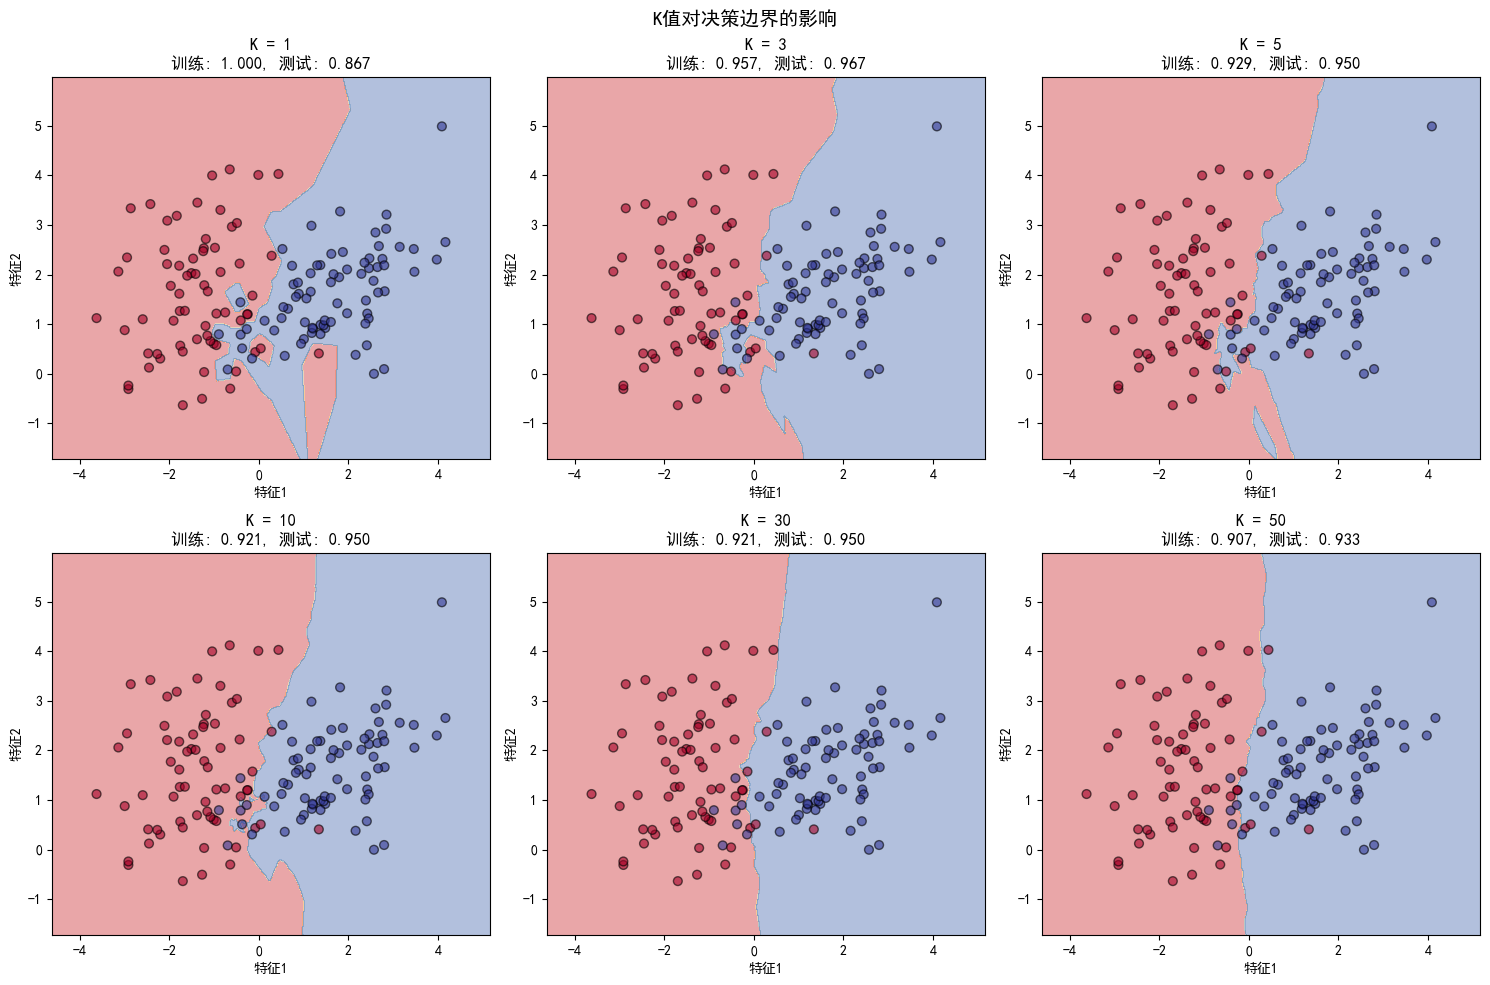


K值选择规律:
----------------------------------------
K小 → 边界复杂 → 容易过拟合
K大 → 边界平滑 → 可能欠拟合

经验法则：K = √n (n为样本数)，且取奇数避免平票


In [12]:
# 不同K值的决策边界对比
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
K_values = [1, 3, 5, 10, 30, 50]

# 生成示例数据， 2个类别
np.random.seed(42)
X, y = make_classification(n_samples=200, n_features=2, n_redundant=0,
                           n_informative=2, n_clusters_per_class=1,
                           class_sep=1.5, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

for idx, K in enumerate(K_values):
    ax = axes[idx // 3, idx % 3]
    
    # 训练KNN
    knn = KNeighborsClassifier(n_neighbors=K)
    knn.fit(X_train, y_train)
    
    # 绘制决策边界
    h = 0.02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h)) # 把横、纵坐标组合成铺满整个平面的网格点
    
    Z = knn.predict(np.c_[xx.ravel(), yy.ravel()]) # 把刚才生成的铺满整个图的网格点，全部丢给 KNN 模型预测一遍
    Z = Z.reshape(xx.shape) # 把预测出来的结果，恢复成网格的形状，方便后面画色块
    
    ax.contourf(xx, yy, Z, alpha=0.4, cmap='RdYlBu')
    ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='RdYlBu',
              s=40, alpha=0.6, edgecolors='k')
    
    train_acc = knn.score(X_train, y_train)
    test_acc = knn.score(X_test, y_test)
    
    ax.set_title(f'K = {K}\n训练: {train_acc:.3f}, 测试: {test_acc:.3f}')
    ax.set_xlabel('特征1')
    ax.set_ylabel('特征2')

plt.suptitle('K值对决策边界的影响', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nK值选择规律:")
print("-" * 40)
print("K小 → 边界复杂 → 容易过拟合")
print("K大 → 边界平滑 → 可能欠拟合")
print("\n经验法则：K = √n (n为样本数)，且取奇数避免平票")


---

## 四、距离度量方法

KNN 是靠 “算距离” 来分类的：距离越近，越像一类。，KNN可以使用不同的距离公式。

1. 欧氏距离（Euclidean）—— 默认、最常用，两点之间的“绝对直线距离”，它就是勾股定理（直角三角形的斜边长度）。
2. 曼哈顿距离（Manhattan）—— 城市街区距离，就是因为有建筑物不能走直线，只能横着走加竖着走（折线距离）。
3. 闵可夫斯基距离（Minkowski）—— 通用公式，上面两种距离的缝合怪，通过调整p值，它就能魔术般地变出欧氏距离、曼哈顿距离以及各种奇奇怪怪的距离，如切比雪夫距离。
4. 余弦相似度（Cosine Similarity）—— 经常使用，衡量的是两个向量在方向上的差异，不关注绝对数值大小。当你想比较两者的“特征模式”或“偏好趋势”是否一致，特别是在高维稀疏数据下（如文本分析、推荐系统），余弦相似度表现更好。
5. 汉明距离（Hamming ）—— 主要用于离散型数据（特别是布尔值、二进制向量或等长字符串）。它的核心概念是计算两个等长数据对象之间，对应位置上不同元素的个数。


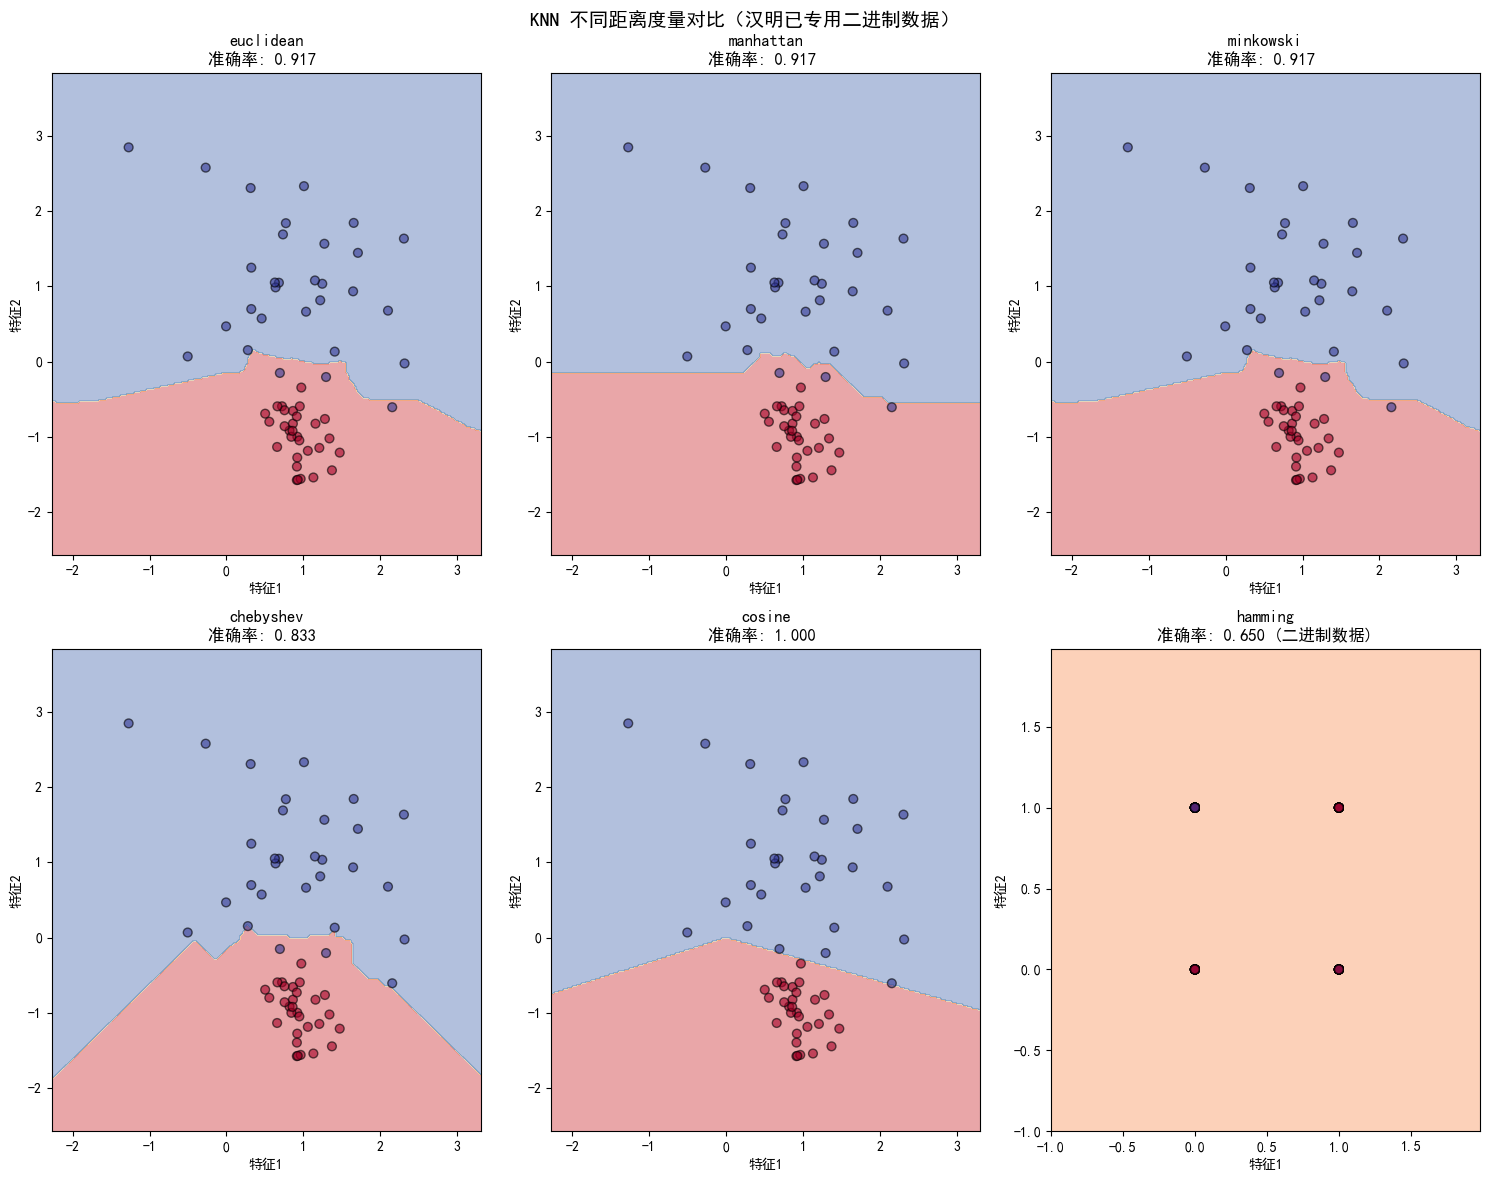

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

# ===================== 1. 原始连续数据（给前5种距离用）=====================
X, y = make_classification(n_samples=60, n_features=2, n_informative=2,
                           n_redundant=0, n_clusters_per_class=1, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ===================== 2. 专门生成 0/1 二值数据（只给汉明距离用）=====================
# 汉明距离只能用在 0 或 1 的离散数据上！
X_binary = np.random.randint(0, 2, size=(100, 2))  # 生成 0/1 数据
y_binary = np.random.randint(0, 2, size=100)
Xb_train, Xb_test, yb_train, yb_test = train_test_split(X_binary, y_binary, test_size=0.2, random_state=42)

# 6种距离
distances = ['euclidean', 'manhattan', 'minkowski', 'chebyshev', 'cosine', 'hamming']

# 2行3列画图
fig, axes = plt.subplots(2, 3, figsize=(15, 12))

for idx, metric in enumerate(distances):
    ax = axes[idx // 3, idx % 3]

    # ===================== 关键：汉明距离单独用二进制数据 =====================
    if metric == 'hamming':
        X_use = X_binary
        y_use = y_binary
        knn = KNeighborsClassifier(n_neighbors=5, metric=metric)
        knn.fit(Xb_train, yb_train)
        title_extra = "(二进制数据)"
    else:
        X_use = X
        y_use = y
        knn = KNeighborsClassifier(n_neighbors=5, metric=metric)
        knn.fit(X_train, y_train)
        title_extra = ""

    # 绘制决策边界
    h = 0.02
    x_min, x_max = X_use[:, 0].min() - 1, X_use[:, 0].max() + 1
    y_min, y_max = X_use[:, 1].min() - 1, X_use[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.4, cmap='RdYlBu')
    ax.scatter(X_use[:, 0], X_use[:, 1], c=y_use, cmap='RdYlBu', s=40, alpha=0.6, edgecolors='k')

    # 准确率
    if metric == 'hamming':
        acc = knn.score(Xb_test, yb_test)
    else:
        acc = knn.score(X_test, y_test)

    ax.set_title(f'{metric}\n准确率: {acc:.3f} {title_extra}')
    ax.set_xlabel('特征1')
    ax.set_ylabel('特征2')

plt.suptitle('KNN 不同距离度量对比（汉明已专用二进制数据）', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

距离度量方法对比:

1. Euclidean (欧氏距离) - 默认
   公式: √(Σ(xi-yi)²)
   特点: 直线距离，适合连续特征

2. Manhattan (曼哈顿距离)
   公式: Σ|xi-yi|
   特点: 街区距离，对异常值更鲁棒

3. Minkowski (闵可夫斯基距离)
   公式: (Σ|xi-yi|^p)^(1/p)
   特点: 欧氏和曼哈顿的通用形式

4. Chebyshev (切比雪夫距离)
   公式: max(|xi-yi|)
   特点: 只考虑最大维度差异

5. Cosine (余弦相似度)
   特点：关注方向，不关注大小，适合高维数据

6. Hamming (汉明距离) ✅专用二进制数据
   公式：统计不同特征值的位数
   特点：只适用于【0/1二进制/离散数据】，连续数据不适用！

---

## 五、KNN的参数详解

来详细看看每个参数的用法：

1. n_neighbors (K值)
   - 默认5
   - 通常3-10之间，或√n
   - 交叉验证选择最优值

2. weights (权重)
   - 'uniform': 所有邻居等权重（默认）
   - 'distance': 距离越近权重越大
   - 自定义函数

3. metric (距离度量)
   - 'minkowski': 默认
   - 'euclidean': 欧氏距离
   - 'manhattan': 曼哈顿距离
   - 'cosine': 余弦相似度（适合文本）

4. algorithm (搜索算法)
   - 'auto': 自动选择
   - 'ball_tree': 球树
   - 'kd_tree': KD树
   - 'brute': 暴力搜索

5. p (Minkowski距离的幂)
   - p=1: 曼哈顿距离
   - p=2: 欧氏距离（默认）

下面我们看一下weights (权重)的两种选项带来的效果。

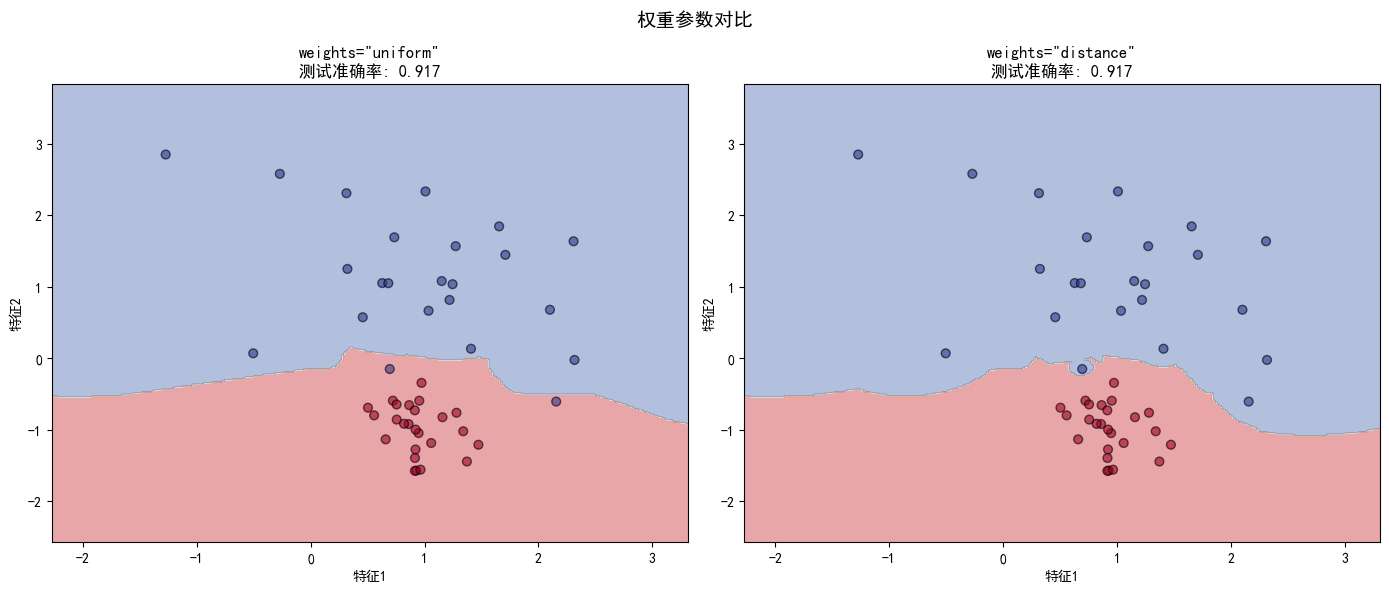

In [23]:
# 权重对比
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for idx, weight in enumerate(['uniform', 'distance']):
    ax = axes[idx]
    
    knn = KNeighborsClassifier(n_neighbors=5, weights=weight)
    knn.fit(X_train, y_train)
    
    # 绘制决策边界
    h = 0.02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    
    Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    ax.contourf(xx, yy, Z, alpha=0.4, cmap='RdYlBu')
    ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='RdYlBu',
              s=40, alpha=0.6, edgecolors='k')
    
    test_acc = knn.score(X_test, y_test)
    ax.set_title(f'weights="{weight}"\n测试准确率: {test_acc:.3f}')
    ax.set_xlabel('特征1')
    ax.set_ylabel('特征2')

plt.suptitle('权重参数对比', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


说明：
- uniform：所有近邻平等投票，决策边界较平滑。
- distance：按距离加权投票，距离越近权重越高，模型更精细、适应性更强。
- 通常 distance 比 uniform 效果更好，因为更尊重 “近邻” 原则。


---

## 六、KNN的优缺点

KNN 简单直觉，但速度慢、怕高维，得知道它的边界：

✅ 优点：
1. 简单直观，易于理解和实现
2. 无训练阶段（惰性学习），新增数据无需重新训练
3. 对数据分布没有假设
4. 适合多分类问题
5. 可用于回归（KNeighborsRegressor）

❌ 缺点：
1. 预测慢：需要计算到所有训练点的距离
2. 对高维数据效果差（维度灾难）
3. 对异常值敏感
4. 需要特征标准化
5. 内存消耗大（需要存储所有训练数据）

🎯 适用场景：
- 样本量不大（<10万）
- 特征维度不高（<20）
- 数据分布不规则
- 需要快速原型验证
- 推荐系统（协同过滤）

⚠️ 不适用场景：
- 大规模数据集
- 高维稀疏数据
- 需要快速预测的场景
- 内存受限的环境


---

## 七、综合实战：手写数字识别

学了一堆理论，来个完整的实战练练手——把前面学的知识点串起来：


In [24]:
print("综合实战：手写数字识别")

from sklearn.datasets import load_digits

# 加载数据
digits = load_digits()
X_digits, y_digits = digits.data, digits.target

print(f"数据形状: {X_digits.shape}")
print(f"图像大小: 8x8 = 64像素")
print(f"类别: 0-9 共{digits.target_names.shape[0]}个数字")

# 划分数据
X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_digits, y_digits, test_size=0.2, random_state=42, stratify=y_digits)

# 标准化（KNN对距离敏感，必须标准化！）
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_d)
X_test_scaled = scaler.transform(X_test_d)

print(f"\n训练集: {X_train_scaled.shape}")
print(f"测试集: {X_test_scaled.shape}")


综合实战：手写数字识别
数据形状: (1797, 64)
图像大小: 8x8 = 64像素
类别: 0-9 共10个数字

训练集: (1437, 64)
测试集: (360, 64)


标准化完成，接下来最关键的一步——选 K 值，我们用5折交叉验证来试：


选择最优K值:
----------------------------------------
K= 1: 交叉验证准确率=0.9756 (+/- 0.0115)
K= 2: 交叉验证准确率=0.9687 (+/- 0.0134)
K= 3: 交叉验证准确率=0.9721 (+/- 0.0151)
K= 4: 交叉验证准确率=0.9701 (+/- 0.0146)
K= 5: 交叉验证准确率=0.9756 (+/- 0.0139)
K= 6: 交叉验证准确率=0.9708 (+/- 0.0157)
K= 7: 交叉验证准确率=0.9701 (+/- 0.0151)
K= 8: 交叉验证准确率=0.9714 (+/- 0.0169)
K= 9: 交叉验证准确率=0.9673 (+/- 0.0170)
K=10: 交叉验证准确率=0.9652 (+/- 0.0183)
K=11: 交叉验证准确率=0.9638 (+/- 0.0176)
K=12: 交叉验证准确率=0.9645 (+/- 0.0155)
K=13: 交叉验证准确率=0.9582 (+/- 0.0162)
K=14: 交叉验证准确率=0.9589 (+/- 0.0142)
K=15: 交叉验证准确率=0.9589 (+/- 0.0139)
K=16: 交叉验证准确率=0.9561 (+/- 0.0154)
K=17: 交叉验证准确率=0.9520 (+/- 0.0160)
K=18: 交叉验证准确率=0.9520 (+/- 0.0160)
K=19: 交叉验证准确率=0.9534 (+/- 0.0134)
K=20: 交叉验证准确率=0.9499 (+/- 0.0157)

最优K值: 1


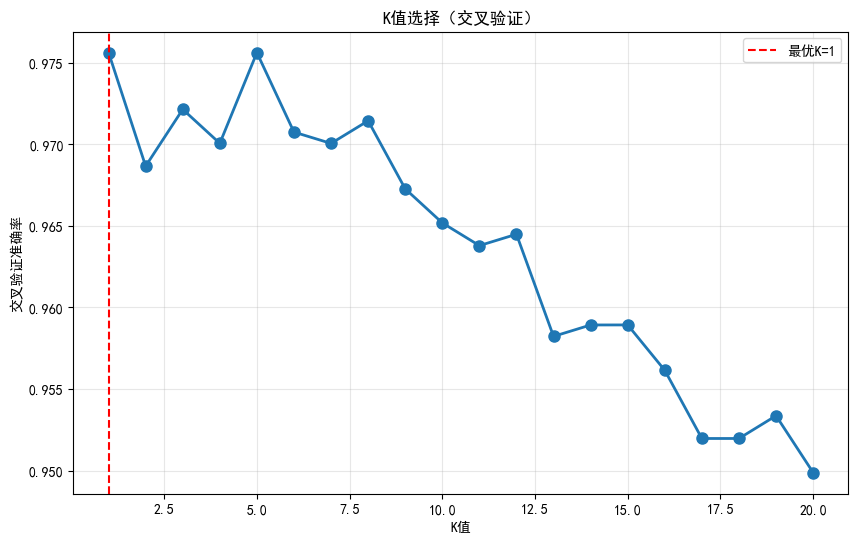

In [26]:
# 选择最优K值
print("\n选择最优K值:")
print("-" * 40)

k_range = range(1, 21)
cv_scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_scaled, y_train_d, cv=5)
    cv_scores.append(scores.mean())
    print(f"K={k:2d}: 交叉验证准确率={scores.mean():.4f} (+/- {scores.std():.4f})")

# 找到最优K
best_k = list(k_range)[np.argmax(cv_scores)]
print(f"\n最优K值: {best_k}")

# 可视化
plt.figure(figsize=(10, 6))
plt.plot(k_range, cv_scores, marker='o', linewidth=2, markersize=8)
plt.axvline(x=best_k, color='r', linestyle='--', label=f'最优K={best_k}')
plt.xlabel('K值')
plt.ylabel('交叉验证准确率')
plt.title('K值选择（交叉验证）')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


找到最优 K 之后，用它训练最终模型，我们用默认的欧氏距离来跑：


In [27]:
# 用最优K训练最终模型
best_knn = KNeighborsClassifier(n_neighbors=best_k)
best_knn.fit(X_train_scaled, y_train_d)

# 评估
train_acc = best_knn.score(X_train_scaled, y_train_d)
test_acc = best_knn.score(X_test_scaled, y_test_d)

print(f"\n最终模型性能 (K={best_k}):")
print("-" * 40)
print(f"训练准确率: {train_acc:.4f}")
print(f"测试准确率: {test_acc:.4f}")

# 详细分类报告
y_pred = best_knn.predict(X_test_scaled)
print("\n分类报告:")
print(classification_report(y_test_d, y_pred))



最终模型性能 (K=1):
----------------------------------------
训练准确率: 1.0000
测试准确率: 0.9667

分类报告:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       0.92      0.97      0.95        36
           2       0.97      0.97      0.97        35
           3       0.97      1.00      0.99        37
           4       0.97      0.94      0.96        36
           5       0.97      1.00      0.99        37
           6       0.97      1.00      0.99        36
           7       0.95      0.97      0.96        36
           8       0.94      0.89      0.91        35
           9       1.00      0.92      0.96        36

    accuracy                           0.97       360
   macro avg       0.97      0.97      0.97       360
weighted avg       0.97      0.97      0.97       360



报告看完了，再可视化一些预测结果，直观感受模型表现：


测试集总数: 360
预测正确: 348 / 360
预测错误: 12 / 360 (错误率: 3.3%)


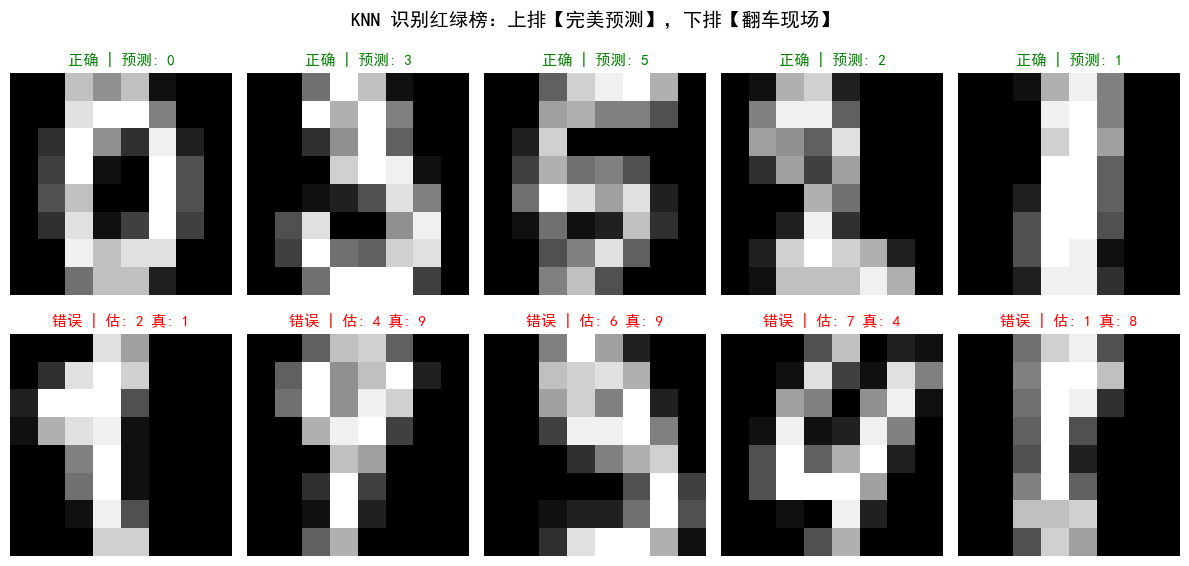

In [32]:
import matplotlib.pyplot as plt
import numpy as np

# 1. 找出所有【预测正确】和【预测错误】的索引
correct_indices = np.where(y_pred == y_test_d)[0]
error_indices = np.where(y_pred != y_test_d)[0]

# 打印基本统计信息
print(f"测试集总数: {len(y_test_d)}")
print(f"预测正确: {len(correct_indices)} / {len(y_test_d)}")
print(f"预测错误: {len(error_indices)} / {len(y_test_d)} (错误率: {(y_pred != y_test_d).mean():.1%})")

# 2. 健壮性检查：确保选出的样本数量足够（防止全对或全错导致代码报错）
num_correct_to_show = min(5, len(correct_indices))
num_error_to_show = min(5, len(error_indices))

# 随机抽取 5 个对的和 5 个错的
selected_correct = np.random.choice(correct_indices, num_correct_to_show, replace=False) if num_correct_to_show > 0 else []
selected_error = np.random.choice(error_indices, num_error_to_show, replace=False) if num_error_to_show > 0 else []

# 3. 创建 2行5列 的画布 (第一行全对，第二行全错)
fig, axes = plt.subplots(2, 5, figsize=(12, 6))

# ---- 第一行：绘制预测正确的案例 ----
for col_idx in range(5):
    ax = axes[0, col_idx]
    if col_idx < len(selected_correct):
        i = selected_correct[col_idx]
        image = X_test_d[i].reshape(8, 8)
        pred = y_pred[i]
        true = y_test_d[i]
        
        ax.imshow(image, cmap='gray')
        ax.set_title(f'正确 | 预测: {pred}', color='green', fontsize=11)
    ax.axis('off')  # 隐藏坐标轴

# ---- 第二行：绘制预测错误的案例 ----
for col_idx in range(5):
    ax = axes[1, col_idx]
    if col_idx < len(selected_error):
        i = selected_error[col_idx]
        image = X_test_d[i].reshape(8, 8)
        pred = y_pred[i]
        true = y_test_d[i]
        
        ax.imshow(image, cmap='gray')
        # 错误案例同时显示预测值和真实值，方便对比
        ax.set_title(f'错误 | 估: {pred} 真: {true}', color='red', fontsize=11)
    else:
        # 如果全对、没有任何错误样本，第二行就留空并写字提示
        if col_idx == 2 and len(selected_error) == 0:
            ax.text(0.5, 0.5, '没有错误案例！', color='green', ha='center', va='center', fontsize=12)
    ax.axis('off')

# 4. 加上大标题并展示
plt.suptitle('KNN 识别红绿榜：上排【完美预测】，下排【翻车现场】', fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

---

## 八、KNN用于回归

KNN 不只是分类器，回归也能做——取 K 个邻居的平均值：


KNN回归示例


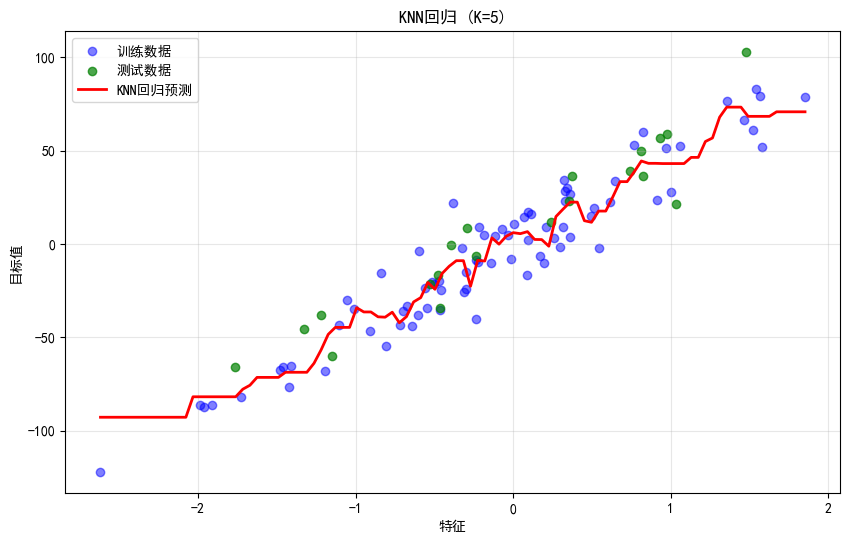


回归性能:
MSE: 239.81
R²: 0.8713


In [33]:
print("KNN回归示例")

from sklearn.neighbors import KNeighborsRegressor
from sklearn.datasets import make_regression

# 生成回归数据
X_reg, y_reg = make_regression(n_samples=100, n_features=1, noise=15, random_state=42)

# 划分数据
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42)

# 训练KNN回归器
knn_reg = KNeighborsRegressor(n_neighbors=5)
knn_reg.fit(X_train_r, y_train_r)

# 预测
X_plot = np.linspace(X_reg.min(), X_reg.max(), 100).reshape(-1, 1)
y_plot = knn_reg.predict(X_plot)

# 可视化
plt.figure(figsize=(10, 6))
plt.scatter(X_train_r, y_train_r, c='blue', alpha=0.5, label='训练数据')
plt.scatter(X_test_r, y_test_r, c='green', alpha=0.7, label='测试数据')
plt.plot(X_plot, y_plot, 'r-', linewidth=2, label='KNN回归预测')
plt.xlabel('特征')
plt.ylabel('目标值')
plt.title('KNN回归 (K=5)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 评估
from sklearn.metrics import mean_squared_error, r2_score
y_pred_r = knn_reg.predict(X_test_r)
print(f"\n回归性能:")
print(f"MSE: {mean_squared_error(y_test_r, y_pred_r):.2f}")
print(f"R²: {r2_score(y_test_r, y_pred_r):.4f}")


---

## 九、小结

| 参数 | 说明 | 建议 |
|------|------|------|
| **n_neighbors (K)** | 邻居数量 | 3-10，或√n |
| **weights** | 权重 | distance通常更好 |
| **metric** | 距离度量 | 欧氏距离通用 |
| **p** | Minkowski幂 | 2（欧氏） |

**KNN vs SVM vs 随机森林**：

| 特性 | KNN | SVM | 随机森林 |
|------|-----|-----|----------|
| 训练速度 | 无训练 | 慢 | 中等 |
| 预测速度 | 慢 | 中等 | 快 |
| 需要标准化 | **是** | **是** | 否 |
| 处理高维 | 差 | 好 | 好 |
| 可解释性 | 强 | 弱 | 中等 |
| 内存占用 | 大 | 小 | 中等 |

---

## 十、课后练习

1. 尝试不同的K值，观察对数字识别准确率的影响
2. 对比标准化前后KNN的性能差异
3. 尝试不同的距离度量（如余弦距离）
4. 用KNN完成一个回归任务
5. 思考：为什么KNN被称为"惰性学习"？

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification, load_iris, load_digits
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, classification_report,
                            confusion_matrix, roc_curve, auc,
                            precision_score, recall_score, f1_score,
                            mean_squared_error, r2_score)
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style='whitegrid')

# seaborn 主题会覆盖字体设置，重新指定中文字体
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False


# 加载手写数字数据
digits = load_digits()
X, y = digits.data, digits.target

# ============================================================
# 练习1：尝试不同的K值，观察对数字识别准确率的影响
# ============================================================
print("=" * 60)
print("练习1：不同K值对数字识别准确率的影响")
print("=" * 60)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 标准化
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

K_values = [1, 3, 5, 7, 9, 11, 15, 21]
train_accs = []
test_accs = []

for k in K_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_s, y_train)
    train_acc = knn.score(X_train_s, y_train)
    test_acc = knn.score(X_test_s, y_test)
    train_accs.append(train_acc)
    test_accs.append(test_acc)
    print(f"  K={k:>2d}: 训练准确率={train_acc:.4f}, 测试准确率={test_acc:.4f}")

best_k = K_values[np.argmax(test_accs)]
print(f"\n最佳K值: {best_k}, 最高测试准确率: {max(test_accs):.4f}")

# 可视化：K值 vs accuracy 曲线
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(K_values, train_accs, 'o-', label='训练集准确率', color='steelblue', linewidth=2, markersize=8)
ax.plot(K_values, test_accs, 's-', label='测试集准确率', color='coral', linewidth=2, markersize=8)
ax.axvline(x=best_k, color='green', linestyle='--', alpha=0.7, label=f'最佳K={best_k}')
ax.set_title('练习1 - K值 vs 准确率曲线（手写数字识别）', fontsize=14)
ax.set_xlabel('K值（近邻数）', fontsize=12)
ax.set_ylabel('准确率', fontsize=12)
ax.set_xticks(K_values)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

for k, tr, te in zip(K_values, train_accs, test_accs):
    ax.annotate(f'{te:.3f}', (k, te), textcoords="offset points", xytext=(0, -15), ha='center', fontsize=8)

plt.tight_layout()
plt.close()

练习1：不同K值对数字识别准确率的影响
  K= 1: 训练准确率=1.0000, 测试准确率=0.9741
  K= 3: 训练准确率=0.9873, 测试准确率=0.9685
  K= 5: 训练准确率=0.9849, 测试准确率=0.9759
  K= 7: 训练准确率=0.9825, 测试准确率=0.9759
  K= 9: 训练准确率=0.9769, 测试准确率=0.9759
  K=11: 训练准确率=0.9753, 测试准确率=0.9722
  K=15: 训练准确率=0.9698, 测试准确率=0.9481
  K=21: 训练准确率=0.9578, 测试准确率=0.9407

最佳K值: 5, 最高测试准确率: 0.9759


In [2]:
# ============================================================
# 练习2：对比标准化前后KNN的性能差异
# ============================================================
print("\n" + "=" * 60)
print("练习2：标准化前后KNN性能对比")
print("=" * 60)

# 故意制造尺度差异
X_dirty = X.copy()
X_dirty[:, :10] *= 100  # 前10个特征放大100倍

X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(X_dirty, y, test_size=0.3, random_state=42)

# 标准化
scaler_d = StandardScaler()
X_train_ds = scaler_d.fit_transform(X_train_d)
X_test_ds = scaler_d.transform(X_test_d)

print(f"\nK=5时标准化前后对比:")
knn_raw = KNeighborsClassifier(n_neighbors=5)
knn_raw.fit(X_train_d, y_train_d)
acc_raw = knn_raw.score(X_test_d, y_test_d)
print(f"  未标准化: {acc_raw:.4f}")

knn_scaled = KNeighborsClassifier(n_neighbors=5)
knn_scaled.fit(X_train_ds, y_train_d)
acc_scaled = knn_scaled.score(X_test_ds, y_test_d)
print(f"  标准化后: {acc_scaled:.4f}")
print(f"  提升: {acc_scaled - acc_raw:.4f}")

# 多个K值对比
print(f"\n不同K值下的对比:")
K_compare = [1, 3, 5, 7, 11]
raw_scores = []
scaled_scores = []
for k in K_compare:
    a1 = KNeighborsClassifier(n_neighbors=k).fit(X_train_d, y_train_d).score(X_test_d, y_test_d)
    a2 = KNeighborsClassifier(n_neighbors=k).fit(X_train_ds, y_train_d).score(X_test_ds, y_test_d)
    raw_scores.append(a1)
    scaled_scores.append(a2)
    print(f"  K={k:>2d}: 原始={a1:.4f}, 标准化={a2:.4f}, 差={a2-a1:+.4f}")

# 可视化
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(K_compare))
w = 0.35
ax.bar(x - w/2, raw_scores, w, label='未标准化', color='coral', alpha=0.8)
ax.bar(x + w/2, scaled_scores, w, label='标准化后', color='steelblue', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels([f'K={k}' for k in K_compare])
ax.set_title('练习2 - 标准化前后KNN性能对比', fontsize=14)
ax.set_ylabel('准确率', fontsize=12)
ax.legend()
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.close()


练习2：标准化前后KNN性能对比

K=5时标准化前后对比:
  未标准化: 0.4407
  标准化后: 0.9759
  提升: 0.5352

不同K值下的对比:
  K= 1: 原始=0.4556, 标准化=0.9741, 差=+0.5185
  K= 3: 原始=0.4519, 标准化=0.9685, 差=+0.5167
  K= 5: 原始=0.4407, 标准化=0.9759, 差=+0.5352
  K= 7: 原始=0.4407, 标准化=0.9759, 差=+0.5352
  K=11: 原始=0.4426, 标准化=0.9722, 差=+0.5296



练习3：不同距离度量对比
  欧氏距离(euclidean): 5折CV均值=0.9690, 标准差=0.0077
  曼哈顿距离(manhattan): 5折CV均值=0.9698, 标准差=0.0082
  余弦距离(cosine): 5折CV均值=0.9563, 标准差=0.0121

K值 × 距离度量的组合:
  K= 3, 欧氏距离: 0.9722
  K= 3, 曼哈顿距离: 0.9730
  K= 3, 余弦距离: 0.9626
  K= 5, 欧氏距离: 0.9690
  K= 5, 曼哈顿距离: 0.9698
  K= 5, 余弦距离: 0.9563
  K= 7, 欧氏距离: 0.9658
  K= 7, 曼哈顿距离: 0.9658
  K= 7, 余弦距离: 0.9578
  K=11, 欧氏距离: 0.9642
  K=11, 曼哈顿距离: 0.9594
  K=11, 余弦距离: 0.9467


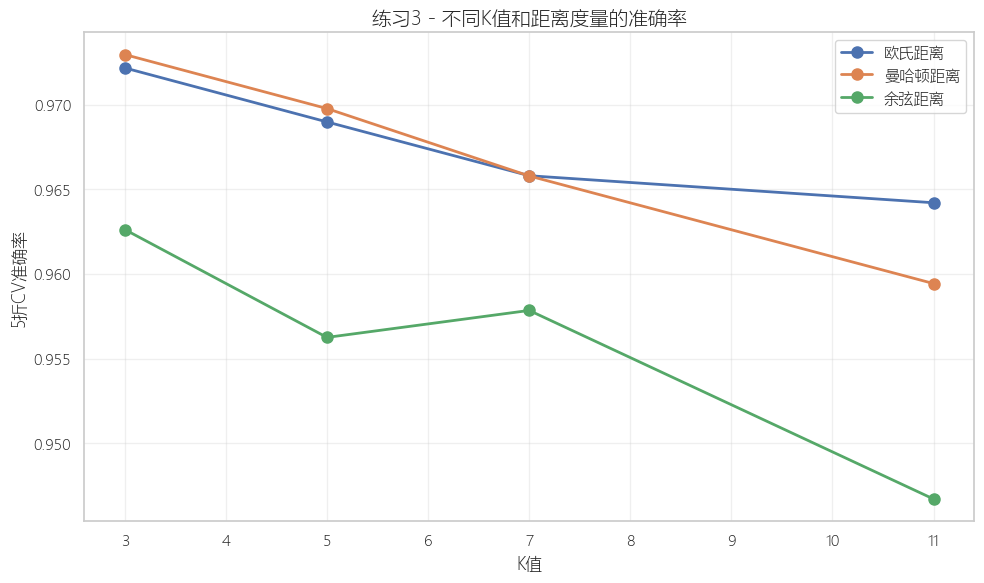

In [3]:
# ============================================================
# 练习3：尝试不同的距离度量
# ============================================================
print("\n" + "=" * 60)
print("练习3：不同距离度量对比")
print("=" * 60)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

metrics = ['euclidean', 'manhattan', 'cosine']
metric_names = {'euclidean': '欧氏距离', 'manhattan': '曼哈顿距离', 'cosine': '余弦距离'}

for metric in metrics:
    scores = cross_val_score(KNeighborsClassifier(n_neighbors=5, metric=metric),
                             X_train_s, y_train, cv=5)
    print(f"  {metric_names[metric]}({metric}): 5折CV均值={scores.mean():.4f}, 标准差={scores.std():.4f}")

# 不同K值 × 不同距离
print(f"\nK值 × 距离度量的组合:")
K_range = [3, 5, 7, 11]
results_matrix = np.zeros((len(K_range), len(metrics)))
for i, k in enumerate(K_range):
    for j, metric in enumerate(metrics):
        scores = cross_val_score(KNeighborsClassifier(n_neighbors=k, metric=metric),
                                 X_train_s, y_train, cv=5)
        results_matrix[i, j] = scores.mean()
        print(f"  K={k:>2d}, {metric_names[metric]}: {scores.mean():.4f}")

# 可视化
fig, ax = plt.subplots(figsize=(10, 6))
for j, metric in enumerate(metrics):
    ax.plot(K_range, results_matrix[:, j], 'o-', label=metric_names[metric],
            linewidth=2, markersize=8)
ax.set_title('练习3 - 不同K值和距离度量的准确率', fontsize=14)
ax.set_xlabel('K值', fontsize=12)
ax.set_ylabel('5折CV准确率', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()


练习4：KNN回归任务

不同K值的KNN回归性能:
  K= 1: RMSE=51.67, R²=0.7627
  K= 3: RMSE=39.09, R²=0.8641
  K= 5: RMSE=38.71, R²=0.8668
  K= 7: RMSE=39.32, R²=0.8626
  K=11: RMSE=42.91, R²=0.8363
  K=15: RMSE=44.33, R²=0.8253
  K=21: RMSE=47.98, R²=0.7953


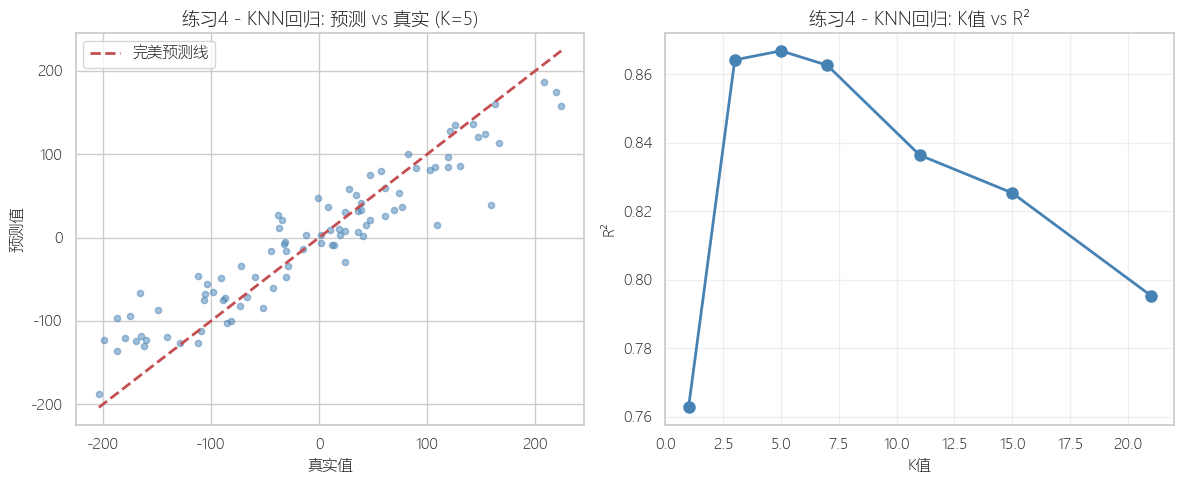

In [4]:
# ============================================================
# 练习4：用KNN完成回归任务
# ============================================================
print("\n" + "=" * 60)
print("练习4：KNN回归任务")
print("=" * 60)

from sklearn.datasets import make_regression

X_reg, y_reg = make_regression(n_samples=300, n_features=5, noise=15, random_state=42)
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg, y_reg, test_size=0.3, random_state=42)

scaler_r = StandardScaler()
X_train_rs = scaler_r.fit_transform(X_train_r)
X_test_rs = scaler_r.transform(X_test_r)

K_values_reg = [1, 3, 5, 7, 11, 15, 21]
print(f"\n不同K值的KNN回归性能:")
for k in K_values_reg:
    knn_reg = KNeighborsRegressor(n_neighbors=k)
    knn_reg.fit(X_train_rs, y_train_r)
    y_pred = knn_reg.predict(X_test_rs)
    rmse = np.sqrt(mean_squared_error(y_test_r, y_pred))
    r2 = r2_score(y_test_r, y_pred)
    print(f"  K={k:>2d}: RMSE={rmse:.2f}, R²={r2:.4f}")

# 可视化：预测 vs 真实
knn_reg_best = KNeighborsRegressor(n_neighbors=5)
knn_reg_best.fit(X_train_rs, y_train_r)
y_pred_r = knn_reg_best.predict(X_test_rs)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(y_test_r, y_pred_r, alpha=0.5, s=20, color='steelblue')
axes[0].plot([y_test_r.min(), y_test_r.max()], [y_test_r.min(), y_test_r.max()],
             'r--', linewidth=2, label='完美预测线')
axes[0].set_xlabel('真实值', fontsize=11)
axes[0].set_ylabel('预测值', fontsize=11)
axes[0].set_title('练习4 - KNN回归: 预测 vs 真实 (K=5)', fontsize=13)
axes[0].legend()

# K值 vs R²
r2_scores = []
for k in K_values_reg:
    knn_r = KNeighborsRegressor(n_neighbors=k)
    knn_r.fit(X_train_rs, y_train_r)
    r2_scores.append(r2_score(y_test_r, knn_r.predict(X_test_rs)))

axes[1].plot(K_values_reg, r2_scores, 'o-', color='steelblue', linewidth=2, markersize=8)
axes[1].set_title('练习4 - KNN回归: K值 vs R²', fontsize=13)
axes[1].set_xlabel('K值', fontsize=11)
axes[1].set_ylabel('R²', fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()

A: 1. KNN在训练阶段（fit）不做任何实质性的模型构建工作：
      - fit() 方法只是简单地将训练数据存储在内存中
      - 没有参数需要学习，没有优化过程，没有模型构建

   2. 所有真正的计算都推迟到预测阶段（predict）才进行：
      - 对每个测试样本，需要计算它与所有训练样本的距离
      - 然后找到K个最近邻，进行投票或平均
      - 预测的时间复杂度是O(n×d)，n是训练样本数，d是特征维度

   3. 与"急切学习"（Eager Learning）的对比：
      - 急切学习（如SVM、逻辑回归）：训练时花大量时间构建模型，
        预测时只需简单的计算
      - 惰性学习（如KNN）：训练时不花时间，预测时需要大量计算

   4. 惰性学习的优缺点：
      - 优点：没有训练时间，新数据可以随时加入训练集
      - 缺点：预测速度慢（尤其数据量大时），内存消耗大（需存储全部数据）

   5. 实际影响：
      - KNN不适合超大数据集（预测太慢）
      - 但适合中小规模数据，尤其是需要快速迭代实验的场景

本篇完整代码包括练习题解答都已经上传至 GitHub 仓库，欢迎 Clone。

---

## 下期预告

> **第 53 篇：模型评估 — 准确率 / 召回率 / F1 / ROC-AUC**
>
> 下篇学模型评估指标——学会用正确的指标判断模型好坏，比单纯追求准确率更重要。

---

*有任何问题，欢迎在评论区留言，小荷会一一回复的！*